## Notebook 4: Inferring Stellar Effective Temperatures with Uncertainty

**Audience:** First-year PhD students in Astrophysics
**Theme:** Probabilistic inference from noisy, degenerate data

###### Motivation

Large surveys give us **huge photometric datasets**, but limited direct physical measurements.

We ask:

> How do we infer stellar properties from noisy, incomplete, and degenerate data?

Here, we estimate **effective temperature** ($T_{\rm eff}$) from photometric colours.

###### Why it’s hard

This is not a simple regression problem:

* **Degeneracy:** different physical conditions can produce similar colours
* **Noise:** measurements have varying uncertainties
* **Nonlinearity:** colour–temperature relations are curved

> We need probabilistic inference, not just prediction.

###### From prediction to probability

We move beyond point estimates to models that capture:

* full **temperature distributions**
* **aleatoric uncertainty** (data noise)
* **epistemic uncertainty** (model uncertainty)

Goal: predictions that include **reliability estimates**.

### Learning goals

###### Physics + statistics

* Why multi-band photometry improves inference
* Why nonlinear models are necessary
* Why log-scaled temperature is used

###### Uncertainty handling

* Heteroscedastic noise modelling
* Aleatoric vs epistemic uncertainty

###### Models

* Deterministic: Random Forest
* Probabilistic: NGBoost
* Distribution-free: Quantile regression

###### Evaluation

* Negative log-likelihood (NLL)
* Calibration curves
* Empirical coverage

### Core formulation

We learn a mapping:

$
(\text{colours}) \rightarrow \log_{10}(T_{\rm eff})
$

while modelling:

* observational noise
* intrinsic scatter
* model uncertainty

and evaluating both **accuracy and confidence**.

###### Big idea

- Instead of asking "Can we predict temperature?"

- We ask "How uncertain are our predictions, and are they reliable?"

A useful astrophysical model must be:

* accurate
* well-calibrated
* uncertainty-aware

> Good models don’t just predict—they know when they might be wrong.


## Imports

We use standard Python tools for data analysis, modelling, and evaluation.

###### Core libraries

* **NumPy**: numerical computing
* **Pandas**: data handling
* **Matplotlib / Seaborn**: visualization
* **SciPy**: statistical utilities

###### Machine learning (scikit-learn)

Used for regression, preprocessing, and model evaluation.

* **Validation & tuning**: `train_test_split`
* **Models**: tree-based and ensemble regressors
* **Metrics**: MSE, MAE, $R^2$

###### Probabilistic models

* **XGBoost**: gradient boosting with quantile regression for uncertainty
* **NGBoost**: models full predictive distributions (Gaussian likelihood, NLL objective)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import scipy.stats as stats
from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


## Reproducibility & readability

We fix the NumPy random seed so results are consistent across runs, including data splits and model initialization.

This ensures:

* **reproducibility** of results
* **debuggable** behaviour
* **scientific reliability** for others

###### scikit-learn

We optionally enable metadata routing to support advanced workflows (e.g. sample weights in pipelines).

###### Visualisation settings

Plots are configured for clarity:

* colorblind-friendly style
* consistent figure size
* larger fonts for readability

These settings make figures easier to interpret and scientifically robust.


In [2]:
SEED = 42
np.random.seed(SEED)

# Optional advanced sklearn configuration (only needed if metadata routing is used later)
sklearn.set_config(enable_metadata_routing=True)

# Plot styling chosen for readability and colorblind accessibility
plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## Loading and validating the stellar dataset

We implement a robust loader with built-in checks to ensure data quality before modelling.

###### 1. File validation

* Checks that the file exists
* Raises an error if reading/parsing fails

###### 2. Structure validation

Ensures required columns are present:

* `Teff`, `u_g`, `g_r`, `r_i`, `i_z`
* `feh`, `sigma_phot`

Stops immediately if anything is missing.

###### 3. Data quality checks

* Removes rows with missing values
* Tracks sample size before/after cleaning
* Errors if no valid data remain

###### Output

Returns a cleaned dataset and reports the number of usable stars, ensuring transparency in preprocessing.


In [3]:
def load_and_validate_stellar_data(file_path):
    """
    Loads stellar photometry and performs multi-layer validation.
    """
    # 1. Systemic Error Handling (File Presence)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        raise IOError(f"Failed to parse CSV: {e}")

    # 2. Structural Validation (Column presence)
    # These are essential for color-temperature inference
    required_columns = ["Teff", "u_g", "g_r", "r_i", "i_z", "feh", "sigma_phot"]
    missing_cols = [col for col in required_columns if col not in df.columns]
    
    if missing_cols:
        raise KeyError(f"Dataset is missing required astronomical features: {missing_cols}")

    # 3. Physical Validation (Filtering Non-Physical Artifacts)
    initial_count = len(df)

    # Drop any rows that have NaN in key features
    df = df.dropna(subset=required_columns)

    final_count = len(df)
    
    if final_count == 0:
        raise ValueError("Data validation failed: No valid stellar samples remain after filtering.")
    
    print(f"Successfully loaded {final_count} stars ({initial_count - final_count} rows discarded).")
    return df

    

In [4]:
# Execution
try:
    df = load_and_validate_stellar_data("sdss_raw_data_v1.csv")
except Exception as err:
    print(f"Pipeline Halted: {err}")


Successfully loaded 9000 stars (0 rows discarded).


## Target transformation

We model stellar temperature in log space:

$
y = \log_{10}(T_{\rm eff})
$

###### Why this helps

* **Scale invariance:** captures relative (not absolute) changes
* **Stability:** reduces skewness and variance
* **Better learning:** improves regression behaviour


In [5]:
# Temperature often behaves more smoothly in logarithmic space.
# - relative errors matter more than absolute Kelvin errors
# - distributions are often better behaved
# - multiplicative trends become additive

df["log_Teff"] = np.log10(df["Teff"])


## Dataset overview

We inspect basic summary statistics of the dataset to understand the ranges, distributions, and potential anomalies in the features and target variable.

This includes counts, means, standard deviations, and quantiles, which provide a quick sanity check before modelling.

In [6]:
df.describe()


,Teff,feh,logg,u_g,g_r,r_i,i_z,sigma_phot,log_Teff
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,5921.448036,-1.092936,3.887953,1.344204,0.470388,0.177754,0.083511,0.019008,3.766937
std,969.823210,0.640558,0.642054,0.432546,0.288319,0.153434,0.114872,0.016866,0.068256
min,4000.670000,-3.496656,0.536516,-0.368490,-0.198250,-2.375800,-0.994720,0.004258,3.602133
25%,5316.064750,-1.513437,3.671977,1.037535,0.294133,0.109138,0.028620,0.008724,3.725590
50%,5732.740000,-1.001560,4.064005,1.240185,0.464845,0.174925,0.075980,0.013492,3.758362
75%,6342.858500,-0.602233,4.320457,1.509960,0.586980,0.234433,0.125548,0.023057,3.802285
max,9417.772000,0.450219,4.881912,3.367600,2.199130,1.716090,2.618490,0.242745,3.973948


## Colour–temperature relation

A single photometric colour already contains significant information about stellar effective temperature. However, the relationship is inherently nonlinear and cannot be captured well by simple linear models.

This plot visualises the mapping between the colour index $g-r$ and the target variable $\log_{10}(T_{\rm eff})$.

###### Physical trend: the stellar main sequence

The diagram reflects the well-known stellar main-sequence behaviour:

- **Hot stars** (high $ \log_{10} T_{\rm eff} $) → small $g-r$ (blue colours)  
- **Cool stars** (low $ \log_{10} T_{\rm eff} $) → large $g-r$ (red colours)  

This monotonic trend encodes the fundamental connection between stellar temperature and emitted spectrum.

###### Nonlinearity of the mapping

The relationship is not linear due to:

- wavelength-dependent stellar атмосpheres  
- nonlinear filter response functions  
- underlying physics of blackbody-like emission with spectral features  

As a result, the colour–temperature relation exhibits clear curvature, indicating that linear regression models will be structurally limited.

###### Scatter around the relation

Instead of lying on a single curve, stars form a band with finite width. This scatter arises from multiple physical and observational effects:

- **Metallicity ($[{\rm Fe/H}]$)**: alters spectral line absorption and shifts observed colours  
- **Interstellar reddening ($E(B-V)$)**: systematically biases colours toward the red  
- **Photometric noise ($\sigma_{\rm phot}$)**: introduces random measurement uncertainty, especially for faint sources  

Together, these effects define an **irreducible spread** in the observed relation, even for stars with identical effective temperatures.

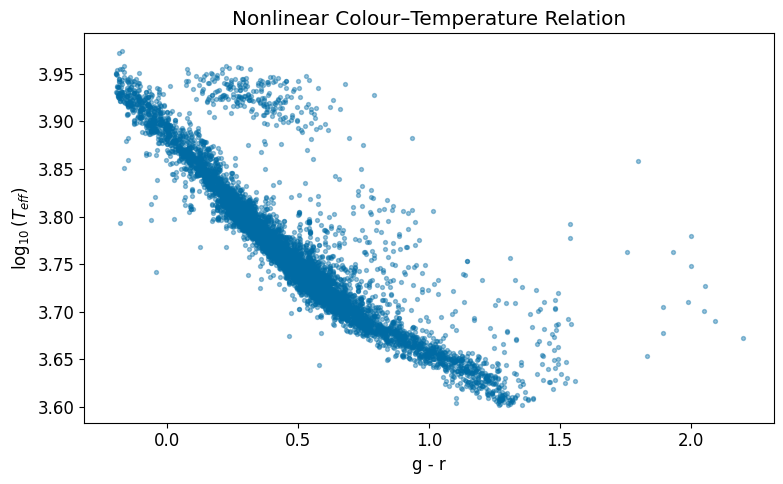

In [7]:
plt.scatter(df["g_r"], df["log_Teff"], s=8, alpha=0.4)
plt.xlabel("g - r")
plt.ylabel(r"$\log_{10}(T_{eff})$")
plt.title("Nonlinear Colour–Temperature Relation")
plt.tight_layout()
plt.show()


## Colour–colour diagram

This plot shows a **colour–colour projection** of the stellar dataset, where each point represents a star in the ($u-g$, $g-r$) plane.

* Each star is plotted using its **photometric colours**:

  * ($u-g$) on the $x$-axis
  * ($g-r$) on the $y$-axis

* Points are **coloured by effective temperature** ($T_{\rm eff}$), allowing us to see how temperature varies across colour space.

###### What it shows

* Stars form a structured locus in colour–colour space
* Temperature varies smoothly along this structure
* Hotter stars tend to occupy one region of the diagram, cooler stars another

###### Why it matters

This visualization highlights that stellar temperature is not directly observed, but **encoded in correlated photometric colours**, motivating multivariate (not single-colour) modelling.


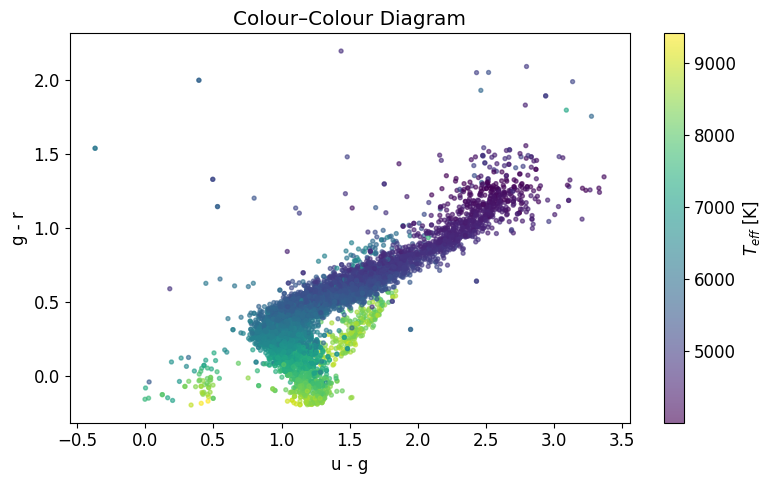

In [8]:
plt.scatter(df["u_g"], df["g_r"], c=df["Teff"], s=8, alpha=0.6, cmap="viridis")
plt.ylabel("g - r")
plt.xlabel("u - g")
plt.title("Colour–Colour Diagram")
plt.colorbar(label=r"$T_{eff}$ [K]")
plt.tight_layout()
plt.show()


## Train / validation / test split and feature construction

To evaluate model performance in a statistically meaningful way, we split the dataset into three disjoint subsets:

* **Training set:** used to fit model parameters
* **Validation set:** used for model selection and early stopping
* **Test set:** held out for final, unbiased evaluation

This separation is essential to ensure that performance estimates reflect **generalisation to unseen stellar samples**, rather than memorisation of the training data.

###### Target variable

We model the logarithm of the stellar effective temperature: $ y = \log_{10}(T_{\rm eff}) $

###### Input features

The model is trained using broadband photometric colours:

* $(u - g)$
* $(g - r)$
* $(r - i)$
* $(i - z)$

These features encode the shape of the stellar spectral energy distribution across different wavelength bands.

They are chosen because:

* they provide a compact representation of stellar spectra
* they are sensitive to temperature-dependent flux variations
* they help partially break degeneracies between stellar populations

No spectroscopic information is used, making this a **photometry-only inference problem**, representative of large-scale survey conditions.

###### Photometric uncertainty

In addition to colours, we retain a separate estimate of observational noise: $\sigma_{\text{phot}}$

This quantity is stored independently from the main feature set and represents the uncertainty associated with each photometric measurement.

It is used later in the modelling pipeline to account for **heteroscedastic observational noise**, i.e. variability in measurement quality across the dataset.

###### Data splitting procedure

The dataset is first split into:

* 75% training + validation
* 25% test

The training + validation subset is then further split into:

* 75% training
* 25% validation

All splits are performed using a fixed random seed to ensure reproducibility.

This results in a consistent partitioning of the data into statistically independent subsets for:

* model fitting
* hyperparameter selection
* final evaluation

###### Feature preparation for uncertainty-aware models

For models that explicitly account for observational quality (e.g. probabilistic or heteroscedastic models), we augment the feature space by including: $\sigma_{\text{phot}}$

This produces an extended input representation:

$
x' = { \text{colours}, \sigma_{\text{phot}} }
$

This augmentation allows the model to condition its predictions on measurement reliability, enabling it to distinguish between:

* intrinsically uncertain stellar configurations
* uncertainty induced by noisy observations

Importantly, this step does not alter the target variable or the underlying physical interpretation, but provides additional context about data quality.

However, since $\sigma_{\text{phot}}$ is itself survey- and instrument-dependent, the model may also partially learn survey-specific structure in addition to astrophysical trends, which should be kept in mind when interpreting its outputs.


In [9]:
# TRAIN / TEST SPLIT

features = ["u_g", "g_r", "r_i", "i_z"]
X = df[features]
y = df["log_Teff"]
sigma = df["sigma_phot"]

X_train_val, X_test, y_train_val, y_test, sig_train_val, sig_test = train_test_split(
    X, y, sigma,
    test_size=0.25,
    random_state=SEED
)


X_train, X_val, y_train, y_val, sig_train, sig_val  = train_test_split(
    X_train_val, y_train_val, sig_train_val,
    test_size=0.25,
    random_state=SEED
)


# Convert explicitly to numpy for consistency
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

sig_train = sig_train.values
sig_val = sig_val.values
sig_test = sig_test.values


X_train_aug = X_train.copy()
X_train_aug["sigma_phot"] = df.loc[X_train.index, "sigma_phot"]

X_val_aug = X_val.copy()
X_val_aug["sigma_phot"] = df.loc[X_val.index, "sigma_phot"]

X_test_aug = X_test.copy()
X_test_aug["sigma_phot"] = df.loc[X_test.index, "sigma_phot"]


## Inverse-variance weighting

Not all stellar measurements are equally reliable, so we weight data by their precision.

###### Method

$
w_{\text{train}} = \frac{1}{\sigma_{\text{train}}^2}
$

More precise measurements contribute more to the loss.

###### Intuition

* small uncertainty → high weight
* large uncertainty → low weight

So high-quality stars dominate learning.

###### Practical details

* clip extreme uncertainties for stability
* normalise weights (mean = 1)
* apply consistently to training and validation sets

###### Effect

* prioritises high signal-to-noise data
* reduces impact of noisy observations
* improves physically meaningful learning


In [10]:
# Avoid division by zero
sig_train_safe = np.clip(sig_train, 1e-4, None)
sig_val_safe = np.clip(sig_val, 1e-4, None)

w_train = 1.0 / sig_train_safe**2
w_val = 1.0 / sig_val_safe**2

# Normalise weights (important for some models)
w_train = w_train / np.mean(w_train)
w_val = w_val / np.mean(w_val)


## Utility functions and evaluation metrics

We use standard regression metrics plus a probabilistic score to evaluate both **prediction accuracy** and **uncertainty quality**.

### Deterministic metrics

###### RMSE

Measures typical error magnitude, with strong penalty on large deviations. Sensitive to outliers and relates to residual variance under Gaussian noise.

###### MAE

Average absolute error. More robust to outliers and easier to interpret in physical units.

###### $R^2$

Explained variance:

* 1 → perfect prediction
* 0 → mean baseline
* < 0 → worse than mean

### Probabilistic metric: Negative Log-Likelihood (NLL)

NLL evaluates the full predicted distribution, not just point estimates.

We assume:

$
y \sim \mathcal{N}(\mu, \sigma)
$

###### Loss function

$
-\log p(y|\mu,\sigma)
= \frac{1}{2}\log(2\pi\sigma^2)
+ \frac{(y-\mu)^2}{2\sigma^2}
$

###### Interpretation

The loss has two competing terms:

* **Uncertainty penalty:** discourages overly confident (tiny $\sigma$) predictions
* **Error term:** penalises wrong predictions, scaled by uncertainty

This enforces a balance between **accuracy and calibration**:

* good means ($\mu \approx y$)
* realistic uncertainties ($\sigma$)
* no overconfidence or inflated uncertainty

###### Objective over dataset

$
\mathcal{L}_{NLL} = \frac{1}{N}\sum_{i=1}^N \left[ \frac{1}{2}\log(2\pi\sigma_i^2) + \frac{(y_i-\mu_i)^2}{2\sigma_i^2} \right]
$


In [11]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "RMSE [dex]": rmse,
        "MAE [dex]": mae,
        "R2": r2
    }


def gaussian_nll(y_true, mu, sigma):
    sigma = np.clip(sigma, 1e-4, None)
    return np.mean(
        0.5 * np.log(2 * np.pi * sigma**2) +
        0.5 * ((y_true - mu)**2 / sigma**2)
    )

## Understanding Uncertainty in Scientific ML

In scientific machine learning, **not all uncertainty is the same**.

A critical failure mode is not just making errors, but **misinterpreting what uncertainty represents**.

We distinguish three fundamentally different regimes:

### 1. Aleatoric Uncertainty (Irreducible Noise)

Aleatoric uncertainty arises from **intrinsic randomness in the data-generating process**. In general:

$
x = g(y) + \epsilon
$

where (\epsilon) captures:

* measurement noise
* intrinsic variability of the system
* unmodeled or stochastic physical processes

Remarkably, we have that 

* **Irreducible** — cannot be removed with more data
* Present even with a perfect model
* Sets a **fundamental noise floor**

That is:

> Even with perfect knowledge of the underlying physics, predictions remain inherently noisy.

### 2. Epistemic Uncertainty (Knowledge Uncertainty)

Epistemic uncertainty arises from **limited knowledge of the mapping between inputs and outputs**.

In ML, this is caused by:

* finite training data
* sparse regions of feature space
* incomplete coverage of the parameter space

Remarkably, we have that 

* **Reducible** with more or better data
* Depends on **training data coverage**
* Should increase in regions where data are scarce

That is:

> The model is uncertain because it has not seen enough similar examples.

### 3. OOD Ignorance (Out-of-Distribution Failure)

This is the most critical and often overlooked regime.

Out-of-distribution (OOD) inputs lie **outside the support of the training data**:

$
x \notin \text{support}(\mathcal{D}_{\text{train}})
$

OOD ignorance is **not simply high epistemic uncertainty**. It is:

> A regime where the model has **no valid basis for inference**.

Remarkably, we have that 

* Cannot be resolved without new data
* Predictions rely entirely on **inductive bias**
* Standard uncertainty estimates often **fail or collapse**

That is:

> The model is not uncertain — it is **uninformed**, but does not recognize this.

###### Uncertainty-aware Regression

Probabilistic regression models predict both:

* a mean prediction (\mu(x))
* an uncertainty estimate (\sigma(x))

A common assumption is:

$
y \sim \mathcal{N}(\mu, \sigma)
$

Training typically minimizes the **negative log-likelihood (NLL)**:

$
-\log P(y|\mu,\sigma)
= \frac{1}{2}\log(2\pi\sigma^2) + \frac{(y-\mu)^2}{2\sigma^2}
$

This objective balances:

* **Fit quality** → penalizes prediction errors
* **Uncertainty calibration** → penalizes unjustified confidence

A well-behaved model should:

* be accurate where the mapping is well constrained
* express higher uncertainty where ambiguity is present
* avoid both **overconfidence** and **excessive uncertainty**

###### Why This Matters for Science

| Type          | Source              | Reducible?            | Model Behavior                 |
| ------------- | ------------------- | --------------------- | ------------------------------ |
| Aleatoric     | Observational noise | No                    | Sets irreducible error floor   |
| Epistemic     | Limited data        | Yes                   | Should increase with sparsity  |
| OOD Ignorance | Outside support     | No (without new data) | Often invisible → catastrophic |

> A model that does not distinguish between epistemic uncertainty and OOD ignorance is **not scientifically reliable**.

In many scientific applications:

* training data are **biased or incomplete**
* large regions of the input space are **unobserved**
* inference often requires **generalization beyond observed data**

###### Practical Consequences

A scientifically trustworthy model should:

* capture **aleatoric noise**
* reflect **epistemic uncertainty** in poorly constrained regions
* **detect or flag OOD inputs explicitly**

Standard ML models often:

* partially capture aleatoric noise
* underestimate epistemic uncertainty
* **fail silently under distribution shift**

> Not all uncertainty is informative.
> The most dangerous failure mode is when a model is **uncertain about noise, but certain about the unknown**.


## Uncertainty from Random Forests (ensemble disagreement, not probabilistic)

Random Forests are **not probabilistic models** in the sense that they do not define a conditional distribution $p(y \mid x)$. 

However, they provide a useful *heuristic signal of uncertainty* through variation across ensemble members.

Each tree $f_t(x)$ is trained on a bootstrap sample with feature randomness, and the final prediction is given by the ensemble mean:

$
\hat{\mu}(x) = \frac{1}{T} \sum_{t=1}^{T} f_t(x)
$

A natural measure of ensemble variability is the sample standard deviation of tree predictions:

$
\hat{\sigma}_{\mathrm{RF}}(x)
\sqrt{
\frac{1}{T - 1}
\sum_{t=1}^{T}
\left(f_t(x) - \hat{\mu}(x)\right)^2
}
$

where $T$ is the number of trees.

This quantity captures **disagreement between bootstrap-trained trees** and can be interpreted as a proxy for **model instability (epistemic uncertainty)**. 

It reflects sensitivity to resampling of the training data, sparsity in feature space, and variability in learned decision boundaries.

However, it is important to stress that this is **not a probabilistic uncertainty estimate**. 

The scale of $\hat{\sigma}_{\mathrm{RF}}$ has no calibrated statistical meaning, and intervals such as $\mu \pm \sigma$ do not correspond to a fixed coverage probability. 

It does not represent aleatoric uncertainty, nor does it arise from a likelihood-based model.

Despite these limitations, ensemble spread remains informative in practice. 

It can highlight regions where the model is less stable or extrapolating: high spread typically indicates model disagreement or sparse data regimes, while low spread suggests stable interpolation. 

In this sense, it is best interpreted as a **relative confidence indicator**, not a calibrated uncertainty estimate.


In [12]:
rf_params = {
    "n_estimators": 539,
    "max_depth": 22,
    "min_samples_leaf": 6,
    "min_samples_split": 12,
    "max_features": "log2", 
}

rf = RandomForestRegressor(
    **rf_params,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train, sample_weight=w_train)

rf_mean_pred_test = rf.predict(X_test)

# Tree-to-tree spread can serve as a crude proxy for predictive uncertainty (specifically epistemic proxy).
# Internal sklearn trees do not retain pandas feature names,
# so convert test matrix to NumPy to avoid warnings.
X_test_np = X_test.to_numpy()

all_tree_preds = np.stack(
    [tree.predict(X_test_np) for tree in rf.estimators_],
    axis=1
)

rf_std_pred_test = np.std(all_tree_preds, axis=1)


## Visualising predictive uncertainty (Random Forest)

We visualise the heuristic interval:

$
\hat{y} \pm \hat{\sigma}_{\text{RF}}
$

###### Important clarification

This band is **not a statistical confidence interval**.

Unlike a Gaussian model, there is no guarantee that this interval corresponds to any fixed coverage probability (e.g. 68%).

###### Interpretation

This plot shows:

* where the model is internally inconsistent (tree disagreement)  
* where predictions are more or less stable  
* how uncertainty varies across feature space  

It should be interpreted qualitatively, not probabilistically.

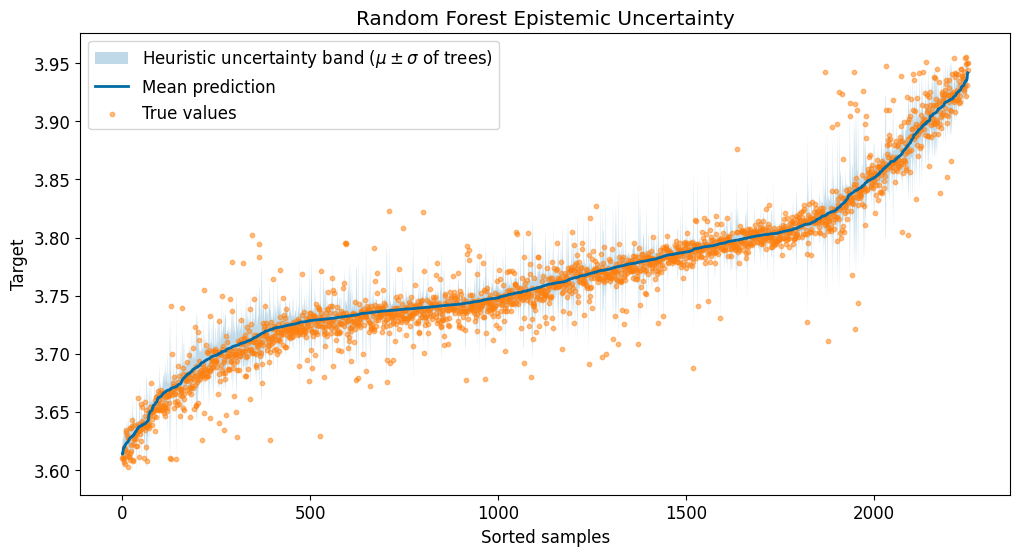

In [13]:
# predictions
rf_low_pred_test  = rf_mean_pred_test - rf_std_pred_test
rf_high_pred_test = rf_mean_pred_test + rf_std_pred_test

# sort by prediction (IMPORTANT for clean plot)
idx = np.argsort(rf_mean_pred_test)

rf_low_pred_test_sorted  = rf_low_pred_test[idx]
rf_mean_pred_test_sorted = rf_mean_pred_test[idx]
rf_high_pred_test_sorted = rf_high_pred_test[idx]

y_test_sorted = y_test[idx]
x = np.arange(len(rf_mean_pred_test_sorted))

plt.figure(figsize=(12,6))

# uncertainty band
plt.fill_between(x, rf_low_pred_test_sorted, rf_high_pred_test_sorted, alpha=0.25, 
                 label=r"Heuristic uncertainty band ($\mu \pm \sigma$ of trees)")

# median prediction
plt.plot(x, rf_mean_pred_test_sorted, label="Mean prediction", linewidth=2)

# true values
plt.scatter(x, y_test_sorted, s=10, alpha=0.5, label="True values")

plt.legend()
plt.title("Random Forest Epistemic Uncertainty")
plt.xlabel("Sorted samples")
plt.ylabel("Target")
plt.show()

## Empirical coverage of heuristic uncertainty bands

We evaluate how often the interval:

$
[\mu - \sigma,\; \mu + \sigma]
$

contains the true value.

###### Important caveat

Because $\sigma_{\mathrm{RF}}$ is **not a calibrated standard deviation**, there is **no theoretical expected coverage** (e.g. 68%).

###### Interpretation

This metric is therefore diagnostic only:

* low coverage → intervals are too narrow relative to errors  
* high coverage → intervals are overly wide  
* no target value → unlike probabilistic models, there is no “correct” level  

This test helps assess whether ensemble spread is at least **monotonically related to error**, but not whether it is statistically calibrated.

In [14]:
rf_inside = np.mean((y_test >= rf_low_pred_test) & (y_test <= rf_high_pred_test))
print("Empirical coverage of [mu-sigma,mu+sigma] interval:", rf_inside)


Empirical coverage of [mu-sigma,mu+sigma] interval: 0.6844444444444444


## Probabilistic evaluation (Gaussian approximation)

We approximate the Random Forest predictions as:

$
y \sim \mathcal{N}(\mu_{\text{RF}}, \sigma_{\text{RF}})
$

###### Critical caveat

This assumption is **not derived from the model** and is imposed purely for comparison.

As a result:

* the likelihood is misspecified  
* the score is not strictly proper for this model  
* absolute values of NLL are not statistically meaningful  

###### Interpretation

NLL can still be used as a **relative diagnostic**:

* lower NLL → better joint behaviour of predictions and spread  
* comparisons to true probabilistic models (e.g. NGBoost) should be made cautiously  

This is best viewed as a **consistency check**, not a principled probabilistic evaluation.

In [15]:
# This assumes Gaussianity and is only approximate
print("RF Approximate Gaussian NLL:",
      gaussian_nll(y_test, rf_mean_pred_test, rf_std_pred_test))


RF Approximate Gaussian NLL: -2.9327861636962322


### Uncertainty–error relationship (Random Forest)

This plot compares the model’s **predicted uncertainty** with its **actual error** per test sample.

* x-axis: ensemble spread $\sigma_{\text{RF}} = \mathrm{std}(f_t(x))$

* y-axis: absolute error $|\hat{y} - y|$

###### What it tests

Whether uncertainty is **meaningful**:

> do higher predicted uncertainties correspond to larger errors?

###### Expected behaviour

A good model shows a **wedge shape**:

* low uncertainty → small errors
* high uncertainty → larger spread in errors

###### Failure modes

* no trend → uninformative uncertainty
* low $\sigma$, high error → overconfident
* high $\sigma$, low error → overly cautious

###### Key takeaway

Good uncertainty should track real error:

> more uncertainty should generally mean higher risk of being wrong.


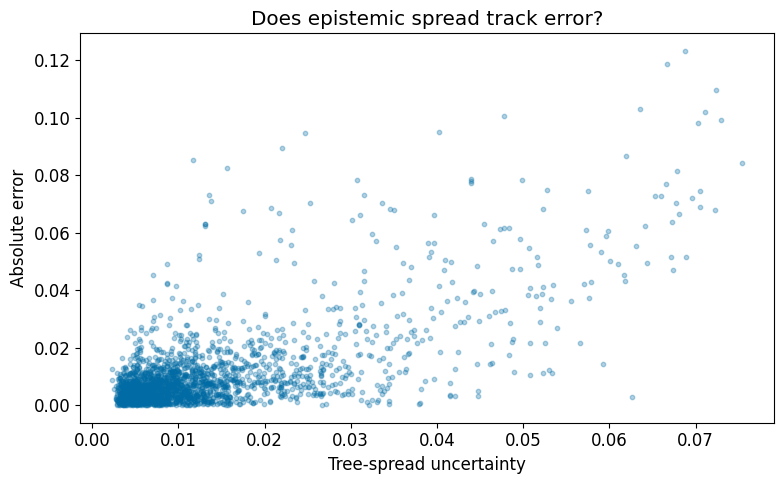

In [16]:
plt.scatter(rf_std_pred_test, np.abs(y_test - rf_mean_pred_test), s=10, alpha=0.3)
plt.xlabel("Tree-spread uncertainty")
plt.ylabel("Absolute error")
plt.title("Does epistemic spread track error?")
plt.tight_layout()
plt.show()



## Uncertainty Reliability Diagram

The reliability diagram is a standard diagnostic tool for evaluating the calibration of probabilistic regression models. 

It compares the **predicted uncertainty** with the **empirically observed errors**, allowing us to assess whether the model’s confidence estimates are statistically meaningful.

###### Definition

For a probabilistic prediction with mean $\mu(x)$ and standard deviation $\sigma(x)$, we compute the normalized residual:

$
z = \frac{|y - \mu(x)|}{\sigma(x)}
$

If the model is well-calibrated and correctly assumes Gaussian errors, then $z$ should follow a standard normal distribution.

###### Construction of the diagram

1. Choose a set of thresholds ($b$) in normalized error space
2. Compute the empirical coverage: <br> $\text{Empirical}(b) = P(z \leq b)$
   
3. Compute the theoretical Gaussian expectation: <br> $\text{Ideal}(b) = 2\Phi(b) - 1$
   where ($\Phi$) is the standard normal CDF.

###### Interpretation

* **Perfect calibration:** empirical curve lies on the diagonal
* **Overconfident model:** empirical curve below diagonal (uncertainty too small)
* **Underconfident model:** empirical curve above diagonal (uncertainty too large)

Unlike standard regression metrics (e.g. RMSE or $R^2$), the reliability diagram evaluates whether predicted uncertainties correspond to real statistical frequencies. 

This is essential in scientific applications where uncertainty estimates are interpreted probabilistically.

A well-calibrated model should not only predict accurately, but also assign uncertainties that reflect true error distributions.


In [17]:
def reliability_diagram(y_true, mu, sigma, n_bins=10, model_name="Model"):
    """
    Regression reliability diagram:
    compares predicted uncertainty vs empirical error distribution.
    """

    sigma = np.clip(sigma, 1e-6, None)
    
    # normalized errors
    z = np.abs((y_true - mu) / sigma)

    # bins in sigma space
    bin_edges = np.linspace(0, 3, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    empirical = []
    ideal = []

    for b in bin_centers:
        empirical.append(np.mean(z <= b))
        ideal.append(2 * stats.norm.cdf(b) - 1)  # symmetric Gaussian interval

    empirical = np.array(empirical)
    ideal = np.array(ideal)

    # plot
    plt.figure(figsize=(6,6))
    plt.plot(ideal, empirical, marker="o", label=model_name)
    plt.plot([0,1],[0,1],"--", color="black", label="Perfect calibration")

    plt.xlabel("Predicted confidence")
    plt.ylabel("Empirical coverage")
    plt.title(f"Reliability Diagram ({model_name})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

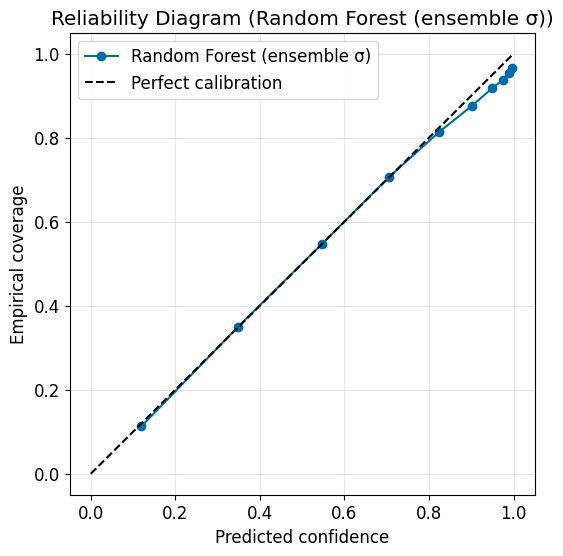

In [18]:
reliability_diagram(
    y_test,
    rf_mean_pred_test,
    rf_std_pred_test,
    model_name="Random Forest (ensemble σ)"
)

## Probabilistic regression with NGBoost (distribution learning)

Standard regression models produce a single point estimate of the target, typically the conditional mean $\hat{y}(x)$.

In contrast, NGBoost directly learns a learns a **parametric approximation to the conditional probability distribution**:

$ p(y \mid x) $

rather than a deterministic output.

###### Gaussian predictive model

In this notebook, we assume a Gaussian likelihood for the target:

$ p(y \mid x) = \mathcal{N}(\mu(x), \sigma^2(x)) $

so each input $x$ is mapped to:

* $\mu(x)$: predicted mean of $\log_{10}(T_{\rm eff})$
* $\sigma(x)$: input-dependent predictive standard deviation

This defines a full predictive distribution over stellar effective temperatures.

###### What NGBoost learns

NGBoost learns two coupled functions:

* a location function $\mu(x)$
* a scale function $\sigma(x)$

using gradient-boosted decision trees.

Unlike standard regression methods, it is trained to optimise the **entire predictive distribution**, not only the mean.

###### Learning objective: negative log-likelihood

The model is trained by minimising the Gaussian negative log-likelihood (NLL):

$
\mathcal{L}_{\mathrm{NLL}} =
\frac{1}{2}\log!\left(2\pi\sigma^2(x)\right)
+
\frac{(y - \mu(x))^2}{2\sigma^2(x)}
$

This couples prediction accuracy and uncertainty estimation in a single objective.

###### Interpretation of the loss

The NLL contains two competing terms:

* **data fit term**
  $\frac{(y - \mu(x))^2}{2\sigma^2(x)}$
  penalises inaccurate predictions

* **uncertainty regularisation term**
  $\frac{1}{2}\log \sigma^2(x)$
  penalises overconfident predictions (too small $\sigma$)

This creates a trade-off between:

> fitting the data accurately and producing well-calibrated uncertainties.

###### Why this is a proper scoring rule

The Gaussian NLL is a **proper scoring rule**, meaning:

* it is minimised when the predicted distribution matches the true data-generating process (under correct specification)
* it penalises both incorrect means and miscalibrated uncertainties
* it discourages degenerate solutions (e.g. arbitrarily large or small variances)

###### Conditioning on observational uncertainty (feature augmentation)

In addition to photometric colours, we explicitly include the **measurement uncertainty of each observation** as an input feature:

* $\sigma_{\text{phot}}$: estimated photometric noise

This is applied consistently across training, validation, and test sets.

###### Why include observational uncertainty?

In astronomical surveys, data quality is not uniform. Photometric measurements exhibit **heteroscedastic noise**, meaning that:

* faint stars tend to have larger uncertainties
* bright stars tend to have smaller uncertainties
* noise levels vary across observations and bands

By providing $\sigma_{\text{phot}}$ as an input, the model can:

* condition predictions on data reliability
* adjust the predicted uncertainty $\sigma(x)$ accordingly
* distinguish between intrinsic astrophysical ambiguity and noise-dominated measurements

###### Probabilistic interpretation

This feature does **not define the target uncertainty directly**, but informs the model about the reliability of the input.

It effectively allows the model to learn:

> the same observed colours may carry different information content depending on measurement precision.

This is especially important in regimes with:

* colour–temperature degeneracies
* strong observational noise
* overlapping stellar populations in feature space

###### Conceptual reformulation

Including $\sigma_{\text{phot}}$ shifts the modelling problem from:

$ p(y \mid x) $

to a more realistic form:

$ p(y \mid x, \sigma_{\text{phot}}) $

reflecting that astronomical inference is fundamentally **measurement-limited**.

###### What NGBoost enables in this context

For stellar photometry, NGBoost provides:

* nonlinear regression from colours to stellar temperature
* heteroscedastic uncertainty $\sigma(x)$ across feature space
* explicit representation of ambiguous or degenerate regions
* a probabilistic framework for photometry-only inference

This is particularly relevant because stellar colour–temperature relations are affected by:

* observational noise
* metallicity variations
* interstellar extinction
* intrinsic degeneracies in colour space

###### Important modelling caveat

Although NGBoost outputs $\mu(x)$ and $\sigma(x)$, interpretation depends on:

* correctness of the Gaussian assumption
* adequacy of the feature representation
* presence of unmodelled latent astrophysical variables

Therefore:

> NGBoost provides a **model-based predictive distribution**, not a guaranteed physical posterior.

###### Training dynamics (log-score)

The validation log-score tracks the evolution of the **predictive log-likelihood** during training.

Lower values correspond to better probabilistic fit and improved calibration.

Early stopping selects the iteration that best balances fit and generalisation.

###### Summary

NGBoost extends boosting to probabilistic regression by directly learning a conditional distribution $p(y \mid x)$ instead of a point estimate.

By incorporating observational uncertainty as an input feature, the model explicitly accounts for varying data quality, enabling more realistic and physically meaningful uncertainty estimates in stellar parameter inference.


[iter 0] loss=-1.2562 val_loss=-1.2986 scale=1.0000 norm=0.5401
[iter 100] loss=-1.3731 val_loss=-1.4079 scale=2.0000 norm=0.9138
[iter 200] loss=-1.4754 val_loss=-1.5050 scale=2.0000 norm=0.8195
[iter 300] loss=-1.5648 val_loss=-1.5902 scale=1.0000 norm=0.3905
[iter 400] loss=-1.6496 val_loss=-1.6732 scale=2.0000 norm=0.7808
[iter 500] loss=-1.7348 val_loss=-1.7570 scale=2.0000 norm=0.8020
[iter 600] loss=-1.8193 val_loss=-1.8405 scale=2.0000 norm=0.8250
[iter 700] loss=-1.8991 val_loss=-1.9197 scale=2.0000 norm=0.8442
[iter 800] loss=-1.9760 val_loss=-1.9964 scale=2.0000 norm=0.8602
[iter 900] loss=-2.0526 val_loss=-2.0726 scale=2.0000 norm=0.8699
[iter 1000] loss=-2.1246 val_loss=-2.1441 scale=2.0000 norm=0.8774
[iter 1100] loss=-2.1946 val_loss=-2.2138 scale=2.0000 norm=0.8842
[iter 1200] loss=-2.2622 val_loss=-2.2809 scale=2.0000 norm=0.8870
[iter 1300] loss=-2.3272 val_loss=-2.3448 scale=2.0000 norm=0.8878
[iter 1400] loss=-2.3881 val_loss=-2.4048 scale=2.0000 norm=0.8898
[iter 1

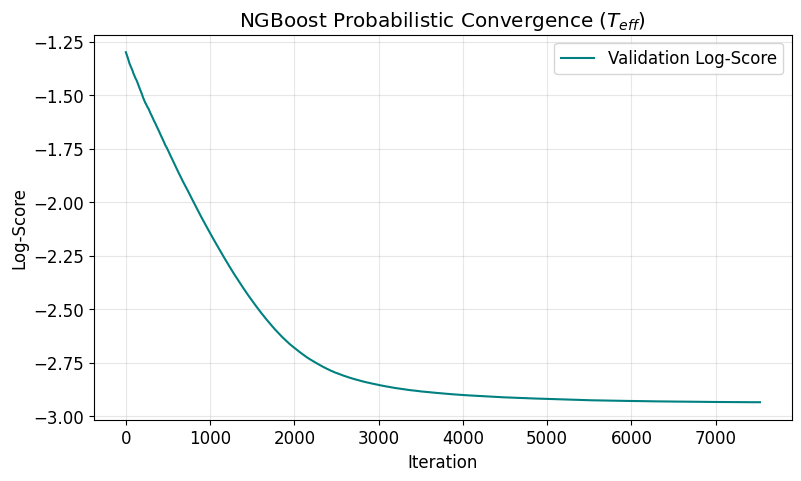

In [19]:
# Initialize the model
ngb = NGBRegressor(
    Dist=Normal, 
    n_estimators=10000, 
    learning_rate=0.001,
    Base=DecisionTreeRegressor(
        max_depth=4, 
        min_samples_leaf=15,   
        max_features='sqrt'   
    ),
    col_sample=0.7,
    verbose=True
)


ngb.fit(
    X_train_aug, y_train, 
#    sample_weight=w_train,
    X_val=X_val_aug, 
    Y_val=y_val,
    early_stopping_rounds=100
)

# Predict as before
ngb_preds_test = ngb.pred_dist(X_test_aug)
ngb_mean_pred_test = ngb_preds_test.loc
ngb_std_pred_test = ngb_preds_test.scale


# The Log-Likelihood score
val_scores = ngb.evals_result["val"]["LOGSCORE"]

plt.figure(figsize=(9, 5))
plt.plot(val_scores, color='teal', label='Validation Log-Score')

# Highlight the best iteration
if hasattr(ngb, 'best_iteration') and ngb.best_iteration is not None:
    plt.axvline(ngb.best_iteration, color='crimson', linestyle='--', 
                label=f'Best iteration: {ngb.best_iteration}')

plt.title("NGBoost Probabilistic Convergence ($T_{eff}$)")
plt.xlabel("Iteration")
plt.ylabel("Log-Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Visualising predictive uncertainty (NGBoost)

NGBoost predicts a mean and uncertainty for each star: $\mu(x), \sigma(x)$

We visualise the interval:

$\mu(x) \pm \sigma(x)$

###### Important clarification

Under a correct Gaussian model, this would correspond to a ~68% prediction interval.

However, in practice this interpretation is only valid if:

* the Gaussian assumption is appropriate  
* the model is well calibrated  

Therefore, this interval should be interpreted as a **model-based uncertainty band**, not guaranteed coverage.

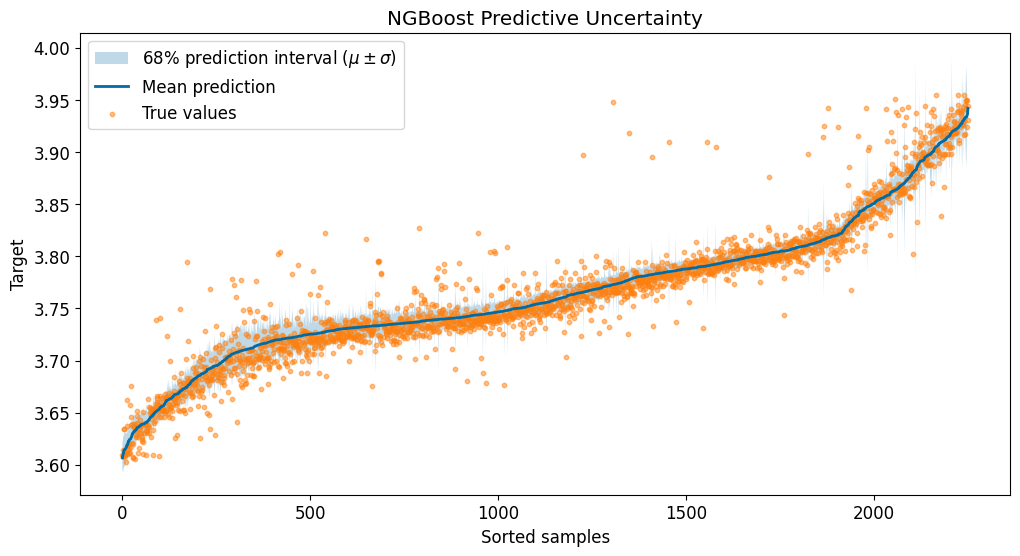

In [20]:
# predictions
ngb_low_pred_test  = ngb_mean_pred_test - ngb_std_pred_test
ngb_high_pred_test = ngb_mean_pred_test + ngb_std_pred_test

# sort by prediction (IMPORTANT for clean plot)
idx = np.argsort(ngb_mean_pred_test)

ngb_low_pred_test_sorted  = ngb_low_pred_test[idx]
ngb_mean_pred_test_sorted = ngb_mean_pred_test[idx]
ngb_high_pred_test_sorted = ngb_high_pred_test[idx]

y_true_sorted = y_test[idx]
x = np.arange(len(ngb_mean_pred_test))

plt.figure(figsize=(12,6))

# uncertainty band
plt.fill_between(x, ngb_low_pred_test_sorted, ngb_high_pred_test_sorted, alpha=0.25, label=r"68% prediction interval $(\mu\pm\sigma)$")

# median prediction
plt.plot(x, ngb_mean_pred_test_sorted, label="Mean prediction", linewidth=2)

# true values
plt.scatter(x, y_true_sorted, s=10, alpha=0.5, label="True values")

plt.legend()
plt.title("NGBoost Predictive Uncertainty")
plt.xlabel("Sorted samples")
plt.ylabel("Target")
plt.show()

### Empirical coverage of NGBoost uncertainty intervals

We compute the fraction of true values inside:

$
[\mu(x) - \sigma(x), \; \mu(x) + \sigma(x)]
$

###### Interpretation

If the model is:

* correctly specified (Gaussian residuals)  
* well calibrated  

then this interval should contain ≈68% of the data.

###### In practice

Deviations from this value indicate:

* **< 68%** → overconfident (uncertainty underestimated)  
* **> 68%** → underconfident (uncertainty overestimated)  

Because real data may violate Gaussian assumptions, this test evaluates **approximate calibration**, not exact probabilistic correctness.

In [21]:
ngb_inside = np.mean((y_test >= ngb_low_pred_test) & (y_test <= ngb_high_pred_test))
print("Empirical coverage of [mu-sigma,mu+sigma] interval:", ngb_inside)


Empirical coverage of [mu-sigma,mu+sigma] interval: 0.6955555555555556


### Probabilistic evaluation (NGBoost via Gaussian NLL)

To assess NGBoost as a probabilistic model, we evaluate it using the Gaussian Negative Log-Likelihood (NLL), treating its outputs as defining a Gaussian predictive distribution:

$
y \sim \mathcal{N}(\mu(x), \sigma(x))
$

Because NGBoost is trained directly by likelihood maximization:

* NLL is consistent with the training objective
* comparisons across models are statistically valid
* uncertainty is part of the learned predictive distribution

However:

> good NLL does not guarantee that the Gaussian assumption is correct


In [22]:
print("NGBoost Approximate Gaussian NLL:",
      gaussian_nll(y_test, ngb_mean_pred_test, ngb_std_pred_test))


NGBoost Approximate Gaussian NLL: -2.848786420522599


### Calibration curve (probabilistic consistency check)

To evaluate whether the predicted uncertainties are statistically reliable, we compute a calibration curve based on normalized residuals.

###### Normalized error

We first standardise prediction errors by the model’s predicted uncertainty:

$
z = \frac{|y - \mu(x)|}{\sigma(x)}
$

This expresses errors in units of “predicted standard deviations”.

###### What is being measured

We then compare:

- **Empirical cumulative probability:** fraction of points with normalized error below a threshold  
- **Theoretical expectation:** cumulative distribution function of a standard normal variable  

###### Ideal behaviour

If the model is well-calibrated *and the Gaussian assumption is appropriate*:

- $z$ should follow a standard normal distribution  
- empirical and theoretical curves should overlap  

This corresponds to uncertainty estimates that correctly reflect real error statistics.

###### Interpretation

- **Empirical curve below ideal:** model is overconfident (uncertainty too small)  
- **Empirical curve above ideal:** model is underconfident (uncertainty too large)  
- **Good alignment:** probabilistic predictions are statistically consistent with observations  

This tests **statistical consistency of the predictive distribution**, not just accuracy.

Calibration evaluates a different aspect of model quality than accuracy:

> a model is well-calibrated if its predicted confidence levels match actual frequencies of error.

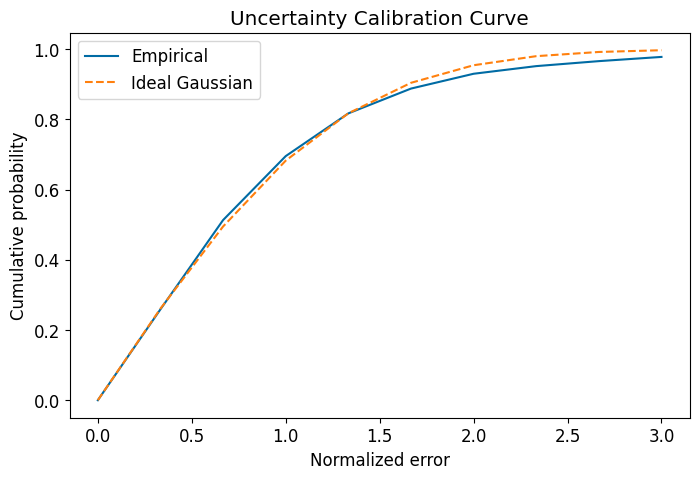

In [23]:
def calibration_curve(y_true, mu, sigma, n_bins=10):
    z = np.abs((y_true - mu) / sigma)
    bins = np.linspace(0, 3, n_bins)
    
    empirical = [np.mean(z <= b) for b in bins]
    theoretical = stats.norm.cdf(bins) * 2 - 1
    
    return bins, empirical, theoretical


bins, emp, theo = calibration_curve(y_test, ngb_mean_pred_test, ngb_std_pred_test)

plt.plot(bins, emp, label="Empirical")
plt.plot(bins, theo, linestyle="--", label="Ideal Gaussian")
plt.xlabel("Normalized error")
plt.ylabel("Cumulative probability")
plt.legend()
plt.title("Uncertainty Calibration Curve")
plt.show()

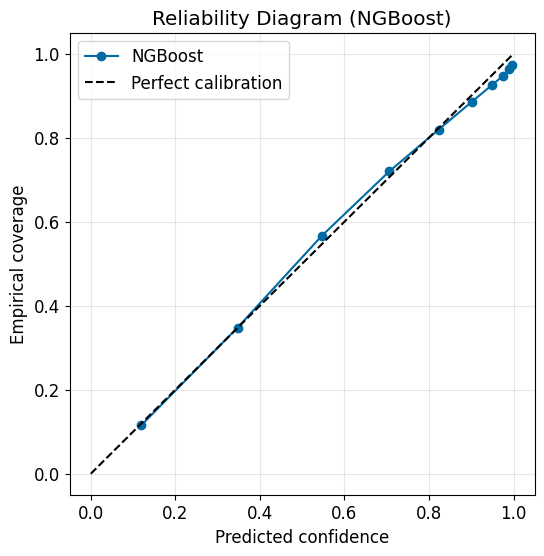

In [24]:
reliability_diagram(
    y_test,
    ngb_mean_pred_test,
    ngb_std_pred_test,
    model_name="NGBoost"
)

## What NGBoost uncertainty represents

### It is:

* likelihood-based predictive uncertainty
* heteroscedastic (input-dependent variance)
* directly trained from data

### It is not:

* a decomposition into epistemic vs aleatoric components
* guaranteed correct under model misspecification
* independent of distributional assumptions


## Probabilistic stellar temperature inference with quantile regression

Standard regression models provide a single point estimate of stellar effective temperature, typically corresponding to the conditional mean or median. 

However, in photometric surveys this is often insufficient: measurement noise, interstellar extinction, and intrinsic stellar diversity can lead to **one-to-many mappings between colours and temperature**.

To represent this ambiguity, we use **quantile regression with gradient-boosted decision trees**, which approximates the conditional distribution of the target by learning specific quantiles rather than a single deterministic prediction.

###### 1. From point prediction to conditional quantiles

Instead of estimating only a central value, we train models to predict selected quantiles of the target distribution:

* $Q_{10}$: lower tail of plausible stellar temperatures
* $Q_{50}$: median estimate (robust central tendency)
* $Q_{90}$: upper tail of plausible temperatures

Together, these define an empirical prediction interval:

$[Q_{10}, ; Q_{90}]$

which can be interpreted as an approximate 80% central predictive range under the model.

This allows us to distinguish between:

* **well-constrained regions** of feature space → narrow intervals
* **degenerate or noisy regions** → wide intervals

###### 2. Training with quantile loss (pinball loss)

Each quantile model is trained independently using the **pinball loss**:

$
L_\alpha(y, \hat{y}) =
\max\big(\alpha (y - \hat{y}), (\alpha - 1)(y - \hat{y})\big)
$

This asymmetric loss function penalises over- and under-prediction differently depending on the quantile level $\alpha$:

* low $\alpha$ (e.g. 0.1): penalises overestimation more strongly
* high $\alpha$ (e.g. 0.9): penalises underestimation more strongly

Each model is therefore specialised to a different part of the conditional distribution.

###### 3. Model implementation (gradient-boosted quantiles)

We use gradient-boosted decision trees (XGBoost) configured for quantile regression. For each quantile level $\alpha \in {0.1, 0.5, 0.9}$, we train a separate model with identical hyperparameters but different loss weighting.

Key aspects of the implementation:

* **Objective:** quantile regression via `reg:quantileerror`
* **Optimization:** gradient boosting over decision trees
* **Early stopping:** used on validation data to prevent overfitting
* **Separate models:** each quantile is trained independently

This results in three distinct predictors:

* low quantile model ($Q_{10}$)
* median model ($Q_{50}$)
* high quantile model ($Q_{90}$)

###### 4. Feature space and conditioning

The model is trained on the augmented feature set:

* photometric colours
* observational uncertainty $\sigma_{\text{phot}}$

This allows the model to condition predictions not only on observed stellar properties but also on **measurement quality**, making the learned quantiles implicitly heteroscedastic.

In practice, this means:

> the predicted uncertainty adapts to both astrophysical variation and observational noise.

###### 5. Quantile crossing limitation

Because each quantile model is trained independently, there is no structural constraint enforcing:

$ Q_{10}(x) \le Q_{50}(x) \le Q_{90}(x) $

As a result, **quantile crossing** may occur, particularly in:

* sparse regions of feature space
* highly noisy observational regimes

This is a known limitation of independent quantile regression and is typically addressed via post-processing or constrained joint models.

###### 6. Interpretation of the prediction interval

The width of the interval:

$ Q_{90}(x) - Q_{10}(x) $

provides an estimate of **predictive uncertainty**, primarily reflecting:

* observational noise
* degeneracies in colour–temperature mapping
* intrinsic astrophysical variability

This corresponds mainly to **aleatoric uncertainty**, rather than epistemic uncertainty about the model itself.

###### 7. Model output structure

After training, each model produces predictions on the test set:

* $Q_{10}(x)$: lower bound
* $Q_{50}(x)$: central estimate
* $Q_{90}(x)$: upper bound

From these, we construct:

* a **prediction interval**
* an **uncertainty width estimator**

This provides a sparse approximation to the conditional quantile function:

$ P(y \mid x) \approx {Q_{10}(x), Q_{50}(x), Q_{90}(x)} $

###### Summary

Quantile regression replaces point estimation with a set of conditional quantiles, allowing the model to represent **distributional uncertainty without assuming a parametric likelihood**. 

In this implementation, gradient-boosted decision trees are used to learn three quantiles independently, producing an interpretable and flexible approximation of the conditional distribution of stellar effective temperature.


In [ ]:
# DATA
xgb_dtrain_aug  = xgb.DMatrix(X_train_aug, label=y_train)#, weight=w_train)
xgb_dval_aug    = xgb.DMatrix(X_val_aug,   label=y_val)#, weight=w_val)
xgb_dtest_aug   = xgb.DMatrix(X_test_aug,  label=y_test)
xgb_y_dtest     = xgb_dtest_aug.get_label()

# TRAINING PARAMETERS
xgb_base_params = {
    "objective": "reg:quantileerror",
    "max_depth": 6,
    "learning_rate": 0.025,
    "subsample": 0.75,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "min_child_weight": 5,
    "gamma": 0.1,
    "max_delta_step": 1,
    "eval_metric": "quantile",
    "verbosity": 0
}

num_boost_round = 10000

# QUANTILES
xgb_alphas = {
    "low": 0.1,
    "mid": 0.5,
    "high": 0.9
}

# TRAIN MODELS
xgb_models = {}
for name, a in xgb_alphas.items():
    print(f"--- Training quantile model: {name} (alpha={a}) ---")

    params = xgb_base_params.copy()
    params["quantile_alpha"] = a

    # The model will monitor the LAST entry in 'evals' (xgb_dtest)
    xgb_models[name] = xgb.train(
        params=params,
        dtrain=xgb_dtrain_aug,
        num_boost_round=num_boost_round,
        evals=[(xgb_dtrain_aug, "train"), (xgb_dval_aug, "val")],
        early_stopping_rounds=100,   # Stop if 'test' quantile loss doesn't improve for 50 rounds
        verbose_eval=100
    )
    
    print(f"Best iteration for {name}: {xgb_models[name].best_iteration}\n")

# PREDICTIONS 
# Note: predict() automatically uses the 'best_iteration' found during early stopping
xgb_low_pred_test    = xgb_models["low"].predict(xgb_dtest_aug)
xgb_median_pred_test = xgb_models["mid"].predict(xgb_dtest_aug)
xgb_high_pred_test   = xgb_models["high"].predict(xgb_dtest_aug)

# UNCERTAINTY INTERVAL
# width of uncertainty
xgb_uncertainty = xgb_high_pred_test - xgb_low_pred_test

# OUTPUT STRUCTURE
xgb_results = {
    "lower": xgb_low_pred_test,
    "median": xgb_median_pred_test,
    "upper": xgb_high_pred_test,
    "uncertainty_width": xgb_uncertainty
}

--- Training quantile model: low (alpha=0.1) ---
[0]	train-quantile:0.01110	val-quantile:0.01047
[100]	train-quantile:0.00458	val-quantile:0.00440
[200]	train-quantile:0.00290	val-quantile:0.00283
[300]	train-quantile:0.00216	val-quantile:0.00221
[400]	train-quantile:0.00182	val-quantile:0.00197
[500]	train-quantile:0.00168	val-quantile:0.00189
[600]	train-quantile:0.00160	val-quantile:0.00186
[700]	train-quantile:0.00155	val-quantile:0.00184
[800]	train-quantile:0.00150	val-quantile:0.00184
[900]	train-quantile:0.00147	val-quantile:0.00184
[1000]	train-quantile:0.00142	val-quantile:0.00183
[1100]	train-quantile:0.00139	val-quantile:0.00183
[1198]	train-quantile:0.00137	val-quantile:0.00183
Best iteration for low: 1098

--- Training quantile model: mid (alpha=0.5) ---
[0]	train-quantile:0.02615	val-quantile:0.02498
[100]	train-quantile:0.00594	val-quantile:0.00587
[200]	train-quantile:0.00432	val-quantile:0.00466
[300]	train-quantile:0.00408	val-quantile:0.00457
[400]	train-quantile:0.

## Quantile regression evaluation (calibration via pinball loss)

To assess how well each quantile model is trained, we use the **quantile (pinball) loss**, which directly matches the optimization objective used during training.

Unlike RMSE or MAE, this loss is **asymmetric**, meaning it penalises over- and under-estimation differently depending on the quantile level $\alpha$.

###### Quantile loss definition

$$
L_\alpha(y,\hat{y}) = \max\big(\alpha (y - \hat{y}), (\alpha - 1)(y - \hat{y})\big)
$$

This structure implies:

- If $y > \hat{y}$ (underprediction), the penalty scales with $\alpha$
- If $y < \hat{y}$ (overprediction), the penalty scales with $(1-\alpha)$

Each model is therefore specialised to a different part of the conditional distribution rather than the mean alone.

###### What is being evaluated

We evaluate three independently trained quantile models:

- **$Q_{10}$ ($\alpha = 0.1$):** lower bound of plausible stellar temperatures  
- **$Q_{50}$ ($\alpha = 0.5$):** median (central tendency)  
- **$Q_{90}$ ($\alpha = 0.9$):** upper bound of plausible stellar temperatures  

The purpose is not to compare them directly, but to verify that each model is consistent with its own probabilistic target.

###### Interpretation of results

- **Lower loss → better alignment with the target quantile**
- $Q_{50}$ behaves similarly to a robust regression estimator
- $Q_{10}$ and $Q_{90}$ assess whether the tails of the distribution are correctly captured

Large discrepancies between losses typically indicate poor calibration or insufficient model capacity in certain regions of feature space.

###### Key idea

This evaluation ensures that:

> each model is not merely producing reasonable-looking bounds, but is actually optimised to represent a specific part of the conditional temperature distribution.

Together, the three quantiles form an empirical reconstruction of the full conditional distribution of stellar effective temperature.

In [ ]:
def quantile_loss(y_true, y_pred, alpha):
    e = y_true - y_pred
    return np.mean(np.maximum(alpha * e, (alpha - 1) * e))

print("Quantile losses:")
print("Q10:", quantile_loss(xgb_y_dtest, xgb_low_pred_test, 0.1))
print("Q50:", quantile_loss(xgb_y_dtest, xgb_median_pred_test, 0.5))
print("Q90:", quantile_loss(xgb_y_dtest, xgb_high_pred_test, 0.9))

### Quantile regression uncertainty (XGBoost)

We visualise the predicted distribution from quantile regression.

Samples are sorted by the median prediction $Q_{50}$ for clarity.

###### Plot contents

* x-axis: sorted by $Q_{50}$
* y-axis: $\log_{10}(T_{\rm eff})$
* line: median $Q_{50}$
* band: $Q_{10}–Q_{90}$ interval
* points: true values

The model expresses **full predictive uncertainty**, showing where stellar temperatures are well-constrained versus ambiguous.


In [ ]:
# sort by prediction (IMPORTANT for clean plot)
idx = np.argsort(xgb_median_pred_test)

xgb_low_pred_test_sorted = xgb_low_pred_test[idx]
xgb_median_pred_test_sorted = xgb_median_pred_test[idx]
xgb_high_pred_test_sorted = xgb_high_pred_test[idx]
xgb_y_test_sorted = xgb_y_dtest[idx]

x = np.arange(len(xgb_median_pred_test))

plt.figure(figsize=(12,6))

# uncertainty band
plt.fill_between(x, xgb_low_pred_test_sorted, xgb_high_pred_test_sorted, alpha=0.25, label="80% prediction interval (Q10-Q90)")

# median prediction
plt.plot(x, xgb_median_pred_test_sorted, label="Median prediction (Q50)", linewidth=2)

# true values
plt.scatter(x, xgb_y_test_sorted, s=10, alpha=0.5, label="True values")

plt.legend()
plt.title("XGBoost Quantile Regression Uncertainty")
plt.xlabel("Sorted samples")
plt.ylabel("Target")
plt.show()

### Empirical coverage of prediction intervals

We check whether predicted uncertainty is statistically reliable by measuring how often true values fall inside the model’s 80% interval.

Fraction of points inside:$[Q_{10}, Q_{90}]$

* $< 0.8$ → overconfident
* $> 0.8$ → too conservative
* $\approx 0.8$ → well calibrated

This tests **probabilistic correctness**, not just accuracy:

> an 80% interval should contain the truth 80% of the time.


In [ ]:
xgb_inside = np.mean((y_test >= xgb_low_pred_test) & (y_test <= xgb_high_pred_test))
print("Empirical coverage of [Q10,Q90] interval:", xgb_inside)


### Measurement noise vs prediction error

This plot compares observational data quality with resulting model performance across different regression approaches.

- **X-axis:** photometric noise ($\sigma_{\text{phot}}$)  
- **Y-axis:** absolute prediction error $|\hat{y} - y|$  

It quantifies how strongly measurement uncertainty propagates into final predictive accuracy.

###### Physical interpretation

In astronomical observations, higher photometric noise corresponds to lower signal-to-noise ratio, which limits the amount of information available about stellar properties.

As a result, even a perfect model cannot fully compensate for poor measurements. This introduces a fundamental limit to predictive performance, often referred to as the **noise floor** of the dataset.

###### Expected behaviour

- **Positive trend:** physically expected, as noisier inputs lead to larger errors  
- **Flat relationship:** may indicate the model is insensitive to data quality (a potential issue)  
- **Increased scatter at high noise:** normal consequence of stochastic measurement uncertainty  

###### Interpretation (aleatoric uncertainty)

This diagnostic primarily reflects **aleatoric uncertainty**, i.e. irreducible noise inherent in the observations.

It demonstrates that:

- high-quality measurements lead to consistently better predictions  
- low-quality measurements impose unavoidable error, independent of model complexity  

This relationship highlights that part of the prediction error is not a modelling failure, but a direct consequence of observational limitations:

> the structure of the data itself sets a lower bound on achievable accuracy.

In [ ]:
plt.scatter(sig_test, np.abs(y_test - rf_mean_pred_test), s=10, alpha=0.5, color="tab:blue", label="Random Forest")
plt.scatter(sig_test, np.abs(y_test - ngb_mean_pred_test), s=10, alpha=0.5, color="tab:orange", label="NGBoost")
plt.scatter(sig_test, np.abs(y_test - xgb_median_pred_test), s=10, alpha=0.5, color="tab:green", label="XGBoost")

plt.xlabel("Photometric noise")
plt.ylabel("Absolute error")
plt.title("Aleatoric noise vs prediction error")
plt.legend()
plt.tight_layout()
plt.show()

### Distribution comparison (KDE plot)

This plot compares the global statistical structure of model predictions against the true distribution of stellar temperatures.

Kernel Density Estimation (KDE) is used to approximate smooth probability density functions from finite samples.

###### What is being compared

- **True distribution:** empirical distribution of the target variable $y$  
- **Predicted distributions:** distributions induced by model outputs  
  - Random Forest mean predictions  
  - NGBoost mean predictions  
  - XGBoost median predictions  

###### Interpretation

This diagnostic evaluates whether the model reproduces the *population-level structure* of the dataset, beyond individual prediction accuracy.

- **Good agreement:** predicted and true distributions align closely  
- **Systematic shift:** global bias (over- or underestimation of temperatures)  
- **Mismatch in spread:** incorrect variance structure (too narrow or too broad predictions)  
- **Missing tails:** poor modelling of rare or extreme stellar populations  

A model can achieve strong point-wise performance (low RMSE, high $R^2$) while still failing to reproduce the correct distribution of astrophysical parameters.

This plot therefore answers a different question:

> does the model learn the *correct distribution of stellar temperatures*, or only approximate individual mappings?

Capturing the correct distribution is essential for population studies, selection effects, and downstream statistical inference in astrophysics.

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(rf_mean_pred_test, label="RF Predicted mean distribution")
sns.kdeplot(ngb_mean_pred_test, label="NGB Predicted mean distribution")
sns.kdeplot(xgb_median_pred_test, label="XGB Predicted median distribution")

sns.kdeplot(y_test, label="True distribution")
plt.legend()
plt.show()

## Model comparison (point prediction performance)

This table summarises the performance of different regression approaches using standard point-estimate metrics.

Each model is evaluated on the same held-out test set using its central prediction:

- Random Forest → mean of trees  
- NGBoost → predicted mean of Gaussian distribution  
- Quantile model → median ($Q_{50}$)

###### Metrics used

- **RMSE:** penalises large errors more strongly; sensitive to outliers  
- **MAE:** average absolute deviation; more robust and directly interpretable  
- **$R^2$:** fraction of variance explained by the model  

###### Interpretation

This comparison focuses purely on **point prediction accuracy**, ignoring uncertainty estimates.

- **Lower RMSE / MAE:** better predictive accuracy  
- **Higher $R^2$:** better explanation of variance in stellar temperatures  

However, differences between models should be interpreted in context:

- Random Forest: strong nonlinear regression baseline  
- NGBoost: similar accuracy, but additionally provides calibrated uncertainty  
- Quantile median: robust central estimator, less sensitive to distributional assumptions  

These metrics do **not** evaluate uncertainty quality.

A model can achieve excellent RMSE while still producing poorly calibrated or misleading uncertainty estimates. 

This is why these results should always be interpreted alongside probabilistic diagnostics (coverage, NLL, calibration curves).

In [ ]:
results = []

results.append(evaluate_model("Random Forest", y_test, rf_mean_pred_test))
results.append(evaluate_model("NGBoost", y_test, ngb_mean_pred_test))
results.append(evaluate_model("Quantile Median", y_test, xgb_median_pred_test))

results_df = pd.DataFrame(results)
print(results_df)


## Scientific interpretation

These results show that broadband photometry encodes enough information to infer stellar effective temperature with high accuracy, but only when nonlinear and probabilistic methods are used.

The key message is not just that prediction is possible, but that **uncertainty is an intrinsic part of the problem**.

###### Main findings

- The colour–temperature relation is strongly **nonlinear** and broadened by astrophysical effects such as metallicity, extinction, and observational noise.  
- The best-performing models are those that can adapt to this structure rather than imposing a simple linear mapping.  
- Photometric noise introduces a **fundamental error floor**, meaning that some uncertainty cannot be eliminated regardless of model complexity.  
- Methods that output distributions (e.g. NGBoost, quantile regression) provide more scientifically useful information than deterministic regressors.  

###### Limitations

- Colour information alone cannot fully resolve degeneracies between temperature, metallicity, and extinction.  
- Random Forest uncertainty is a heuristic (tree spread) and not a calibrated probabilistic estimate.  
- Quantile regression captures **aleatoric uncertainty** but does not represent a full likelihood model.  
- Survey systematics and selection effects are not explicitly modelled, limiting astrophysical generalisation.  


## Conclusion

Inferring stellar parameters from photometry is fundamentally a problem of **probabilistic inference under incomplete and noisy information**.

Reliable scientific modelling in this regime requires three ingredients:

- physically meaningful feature construction  
- statistically consistent learning frameworks  
- rigorous evaluation of uncertainty, not just accuracy  

In this setting, the goal is not only to predict stellar temperatures, but to quantify how trustworthy those predictions are.